In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/online_retail_II.csv", parse_dates=["InvoiceDate"],
                 dtype={"Invoice": str, "StockCode": str})
print(df.shape)
df.head()

(341544, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,23143,HAND WARMER OWL DESIGN,1,2009-12-01 08:10:00,1.25,17566.0,United Kingdom
1,489434,22574,DOLLY GIRL LUNCH BOX,7,2009-12-01 08:10:00,3.75,17566.0,United Kingdom
2,489434,22000,RED TOADSTOOL LED NIGHT LIGHT,1,2009-12-01 08:10:00,1.65,17566.0,United Kingdom
3,489434,20660,METAL SIGN TAKE IT OR LEAVE IT,4,2009-12-01 08:10:00,7.95,17566.0,United Kingdom
4,489434,22105,HEART OF WICKER SMALL,3,2009-12-01 08:10:00,3.75,17566.0,United Kingdom


In [3]:
df.info()
print("\nMissing values:\n", df.isna().sum())
print("\nCancelled invoices:", df["Invoice"].str.startswith("C").sum())
print("Duplicate rows:", df.duplicated().sum())
print("Zero/negative price:", (df["Price"] <= 0).sum())
print("Date range:", df["InvoiceDate"].min(), "->", df["InvoiceDate"].max())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 341544 entries, 0 to 341543
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      341544 non-null  object        
 1   StockCode    341544 non-null  object        
 2   Description  340197 non-null  object        
 3   Quantity     341544 non-null  int64         
 4   InvoiceDate  341544 non-null  datetime64[ns]
 5   Price        341544 non-null  float64       
 6   Customer ID  279175 non-null  float64       
 7   Country      341544 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 20.8+ MB

Missing values:
 Invoice            0
StockCode          0
Description     1347
Quantity           0
InvoiceDate        0
Price              0
Customer ID    62369
Country            0
dtype: int64

Cancelled invoices: 6159
Duplicate rows: 1699
Zero/negative price: 697
Date range: 2009-12-01 08:10:00 -> 20

In [4]:
raw_rows = len(df)

df = df.drop_duplicates()
df = df.dropna(subset=["Customer ID"])
df = df[~df["Invoice"].str.startswith("C")]               # To remove cancelled orders
df = df[(df["Quantity"] > 0) & (df["Price"] > 0)]
df = df[~df["StockCode"].isin(["POST", "DOT"])]           # No postage product

df["Customer ID"] = df["Customer ID"].astype(int)
df["Revenue"] = df["Quantity"] * df["Price"]

print(f"Rows: {raw_rows:,} -> {len(df):,}  ({len(df)/raw_rows:.1%} bache)")
print("Unique customers:", df["Customer ID"].nunique())
df.head()

Rows: 341,544 -> 261,431  (76.5% bache)
Unique customers: 5877


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,23143,HAND WARMER OWL DESIGN,1,2009-12-01 08:10:00,1.25,17566,United Kingdom,1.25
1,489434,22574,DOLLY GIRL LUNCH BOX,7,2009-12-01 08:10:00,3.75,17566,United Kingdom,26.25
2,489434,22000,RED TOADSTOOL LED NIGHT LIGHT,1,2009-12-01 08:10:00,1.65,17566,United Kingdom,1.65
3,489434,20660,METAL SIGN TAKE IT OR LEAVE IT,4,2009-12-01 08:10:00,7.95,17566,United Kingdom,31.80
4,489434,22105,HEART OF WICKER SMALL,3,2009-12-01 08:10:00,3.75,17566,United Kingdom,11.25


In [5]:

df["InvoiceMonth"] = df["InvoiceDate"].dt.to_period("M")

df["CohortMonth"] = (df.groupby("Customer ID")["InvoiceDate"]
                       .transform("min").dt.to_period("M"))

df["CohortIndex"] = ((df["InvoiceMonth"].dt.year  - df["CohortMonth"].dt.year) * 12 +
                     (df["InvoiceMonth"].dt.month - df["CohortMonth"].dt.month))

df[["Customer ID", "InvoiceMonth", "CohortMonth", "CohortIndex"]].head()

,Customer ID,InvoiceMonth,CohortMonth,CohortIndex
0,17566,2009-12,2009-12,0
1,17566,2009-12,2009-12,0
2,17566,2009-12,2009-12,0
3,17566,2009-12,2009-12,0
4,17566,2009-12,2009-12,0


In [6]:
cohort_data = (df.groupby(["CohortMonth", "CohortIndex"])["Customer ID"]
                 .nunique().reset_index())

cohort_counts = cohort_data.pivot(index="CohortMonth",
                                  columns="CohortIndex",
                                  values="Customer ID")
cohort_counts.index = cohort_counts.index.astype(str)
cohort_counts

CohortIndex,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
CohortMonth,,,,,,,,,,,,,,,,,,,,,
2009-12,618.0,159.0,152.0,149.0,136.0,149.0,127.0,130.0,107.0,155.0,...,96.0,96.0,97.0,97.0,101.0,84.0,119.0,108.0,115.0,72.0
2010-01,356.0,90.0,82.0,80.0,84.0,79.0,85.0,74.0,109.0,94.0,...,58.0,62.0,69.0,52.0,53.0,74.0,67.0,63.0,45.0,NaN
2010-02,348.0,101.0,96.0,84.0,95.0,83.0,84.0,112.0,111.0,92.0,...,65.0,75.0,57.0,67.0,84.0,68.0,64.0,64.0,NaN,NaN
2010-03,222.0,57.0,55.0,44.0,53.0,55.0,65.0,57.0,62.0,49.0,...,35.0,40.0,35.0,61.0,42.0,44.0,29.0,NaN,NaN,NaN
2010-04,216.0,65.0,54.0,51.0,51.0,63.0,58.0,65.0,42.0,36.0,...,42.0,39.0,48.0,39.0,47.0,31.0,NaN,NaN,NaN,NaN
2010-05,220.0,52.0,52.0,44.0,75.0,57.0,53.0,41.0,31.0,47.0,...,31.0,48.0,45.0,44.0,34.0,NaN,NaN,NaN,NaN,NaN
2010-06,195.0,58.0,58.0,82.0,60.0,76.0,39.0,51.0,44.0,43.0,...,55.0,56.0,54.0,29.0,NaN,NaN,NaN,NaN,NaN,NaN
2010-07,194.0,58.0,76.0,61.0,60.0,53.0,45.0,52.0,46.0,32.0,...,48.0,49.0,38.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08,210.0,79.0,72.0,78.0,59.0,55.0,39.0,45.0,46.0,42.0,...,48.0,35.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
cohort_size = cohort_counts[0]
retention = cohort_counts.divide(cohort_size, axis=0).mul(100).round(1)
retention

CohortIndex,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
CohortMonth,,,,,,,,,,,,,,,,,,,,,
2009-12,100.0,25.7,24.6,24.1,22.0,24.1,20.6,21.0,17.3,25.1,...,15.5,15.5,15.7,15.7,16.3,13.6,19.3,17.5,18.6,11.7
2010-01,100.0,25.3,23.0,22.5,23.6,22.2,23.9,20.8,30.6,26.4,...,16.3,17.4,19.4,14.6,14.9,20.8,18.8,17.7,12.6,NaN
2010-02,100.0,29.0,27.6,24.1,27.3,23.9,24.1,32.2,31.9,26.4,...,18.7,21.6,16.4,19.3,24.1,19.5,18.4,18.4,NaN,NaN
2010-03,100.0,25.7,24.8,19.8,23.9,24.8,29.3,25.7,27.9,22.1,...,15.8,18.0,15.8,27.5,18.9,19.8,13.1,NaN,NaN,NaN
2010-04,100.0,30.1,25.0,23.6,23.6,29.2,26.9,30.1,19.4,16.7,...,19.4,18.1,22.2,18.1,21.8,14.4,NaN,NaN,NaN,NaN
2010-05,100.0,23.6,23.6,20.0,34.1,25.9,24.1,18.6,14.1,21.4,...,14.1,21.8,20.5,20.0,15.5,NaN,NaN,NaN,NaN,NaN
2010-06,100.0,29.7,29.7,42.1,30.8,39.0,20.0,26.2,22.6,22.1,...,28.2,28.7,27.7,14.9,NaN,NaN,NaN,NaN,NaN,NaN
2010-07,100.0,29.9,39.2,31.4,30.9,27.3,23.2,26.8,23.7,16.5,...,24.7,25.3,19.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08,100.0,37.6,34.3,37.1,28.1,26.2,18.6,21.4,21.9,20.0,...,22.9,16.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


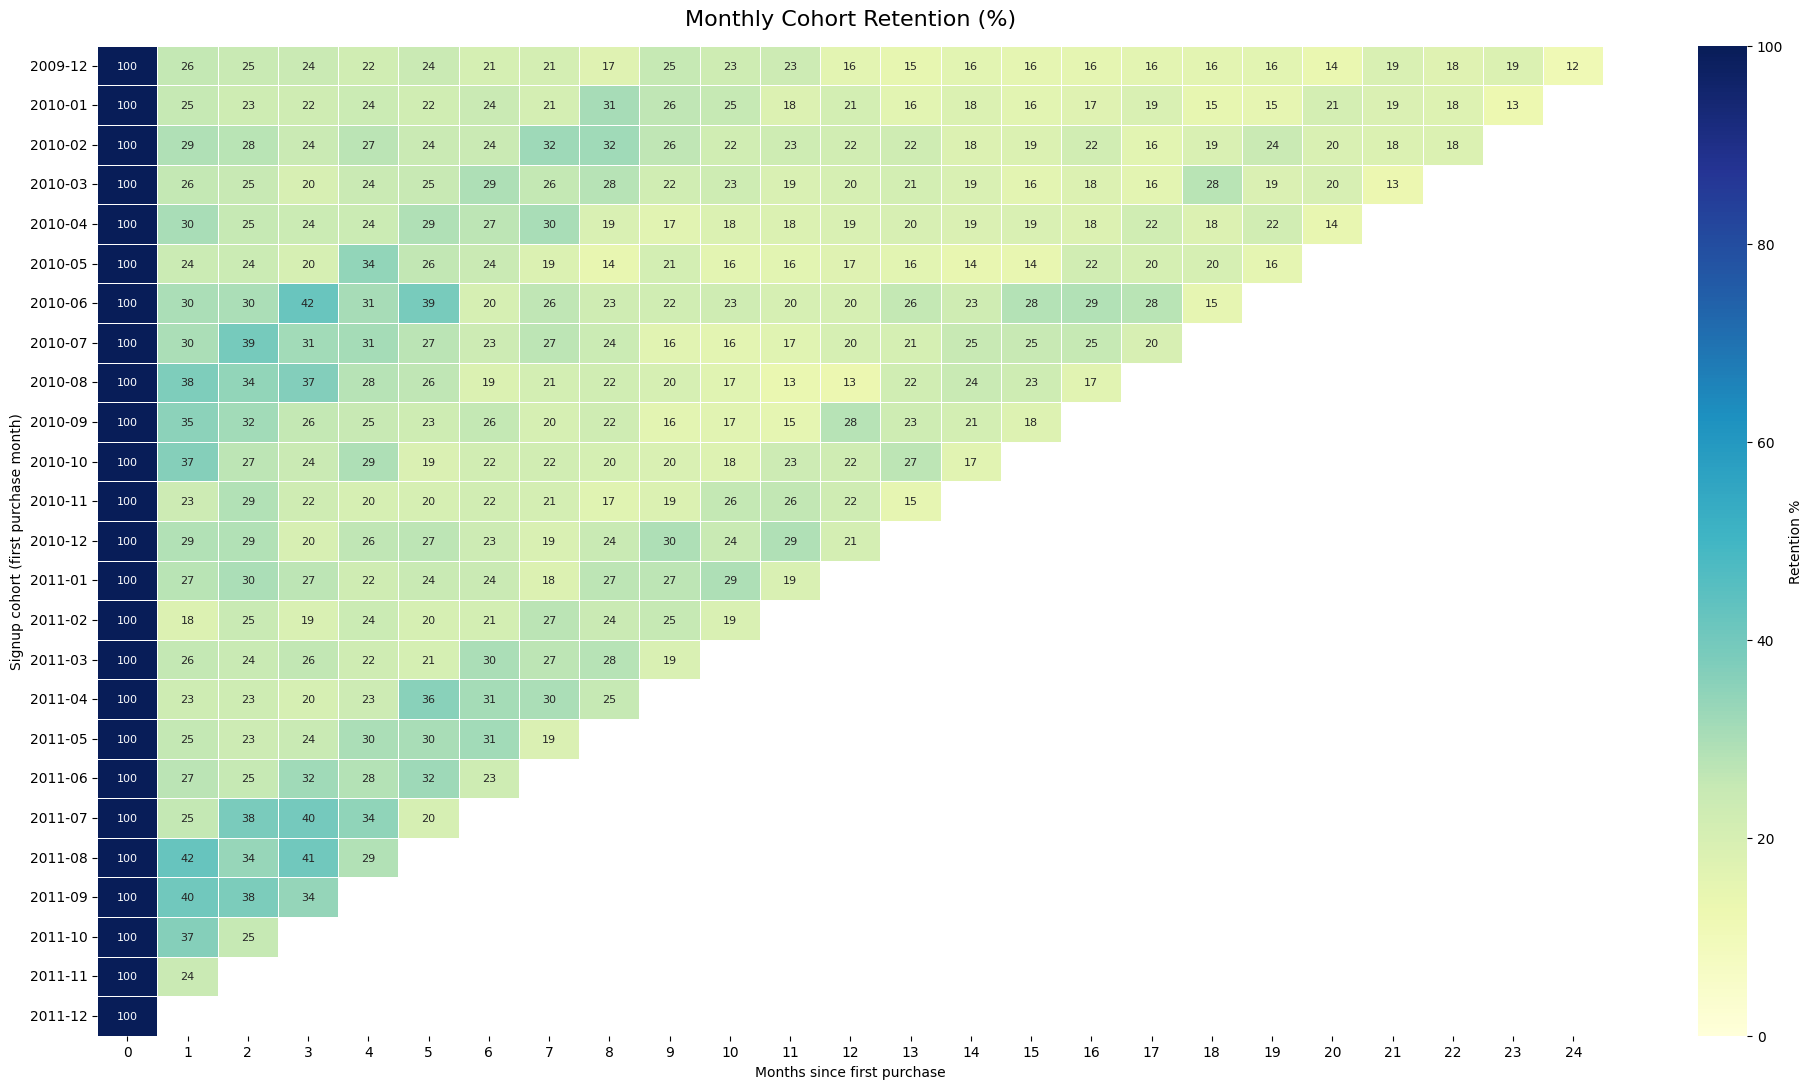

In [8]:
plt.figure(figsize=(20, 11))
sns.heatmap(retention, annot=True, fmt=".0f", cmap="YlGnBu",
            vmin=0, vmax=100, linewidths=0.4,
            cbar_kws={"label": "Retention %"}, annot_kws={"size": 8})
plt.title("Monthly Cohort Retention (%)", fontsize=16, pad=15)
plt.xlabel("Months since first purchase")
plt.ylabel("Signup cohort (first purchase month)")
plt.tight_layout()
plt.savefig("cohort_heatmap.png", dpi=200)
plt.show()

Average retention:
  Month  1: 29.0%
  Month  3: 27.2%
  Month  6: 24.4%
  Month 12: 20.2%

Cohort sizes (top 3):
 CohortMonth
2009-12    618.0
2010-01    356.0
2010-02    348.0
Name: 0, dtype: float64

Best Month-1 cohorts:
 CohortMonth
2011-08    42.5
2011-09    40.4
2010-08    37.6
Name: 1, dtype: float64

Worst Month-1 cohorts:
 CohortMonth
2011-02    18.2
2011-04    22.8
2010-11    23.2
Name: 1, dtype: float64


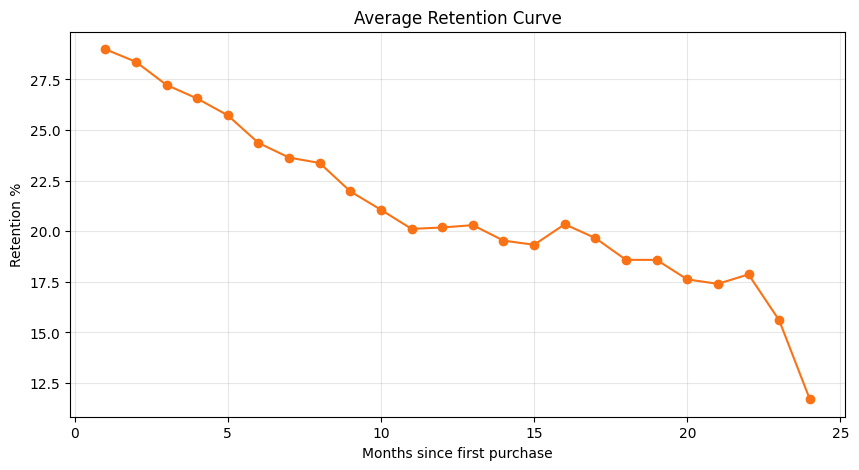

In [9]:
avg_ret = retention.drop(columns=0).mean()

print("Average retention:")
for m in [1, 3, 6, 12]:
    print(f"  Month {m:>2}: {avg_ret[m]:.1f}%")

print("\nCohort sizes (top 3):\n", cohort_size.sort_values(ascending=False).head(3))
print("\nBest Month-1 cohorts:\n",  retention[1].sort_values(ascending=False).head(3))
print("\nWorst Month-1 cohorts:\n", retention[1].sort_values().head(3))

# Average retention curve
plt.figure(figsize=(10, 5))
avg_ret.plot(marker="o", color="#f97316")
plt.title("Average Retention Curve"); plt.xlabel("Months since first purchase")
plt.ylabel("Retention %"); plt.grid(alpha=0.3)
plt.show()

In [10]:
import sqlite3

sales = df[["Invoice", "StockCode", "Quantity", "InvoiceDate", "Price",
            "Customer ID", "Country", "Revenue"]].copy()
sales = sales.rename(columns={"Customer ID": "CustomerID"})
sales["InvoiceDate"] = sales["InvoiceDate"].dt.strftime("%Y-%m-%d %H:%M:%S")

conn = sqlite3.connect("retail.db")
sales.to_sql("sales", conn, if_exists="replace", index=False)

# Check
pd.read_sql("SELECT COUNT(*) AS rows, COUNT(DISTINCT CustomerID) AS customers FROM sales", conn)

,rows,customers
0,261431,5877


In [11]:
query = """
WITH orders AS (
    -- har customer ke active months (duplicate hata ke)
    SELECT DISTINCT CustomerID,
           strftime('%Y-%m', InvoiceDate) AS InvoiceMonth
    FROM sales
),
cohort AS (
    -- customer ki first purchase month = cohort
    SELECT CustomerID, MIN(InvoiceMonth) AS CohortMonth
    FROM orders
    GROUP BY CustomerID
),
activity AS (
    -- first purchase ke kitne mahine baad aaya
    SELECT o.CustomerID,
           c.CohortMonth,
           (CAST(substr(o.InvoiceMonth, 1, 4) AS INT) - CAST(substr(c.CohortMonth, 1, 4) AS INT)) * 12
         + (CAST(substr(o.InvoiceMonth, 6, 2) AS INT) - CAST(substr(c.CohortMonth, 6, 2) AS INT))
           AS CohortIndex
    FROM orders o
    JOIN cohort c ON o.CustomerID = c.CustomerID
),
cohort_counts AS (
    SELECT CohortMonth, CohortIndex, COUNT(DISTINCT CustomerID) AS Customers
    FROM activity
    GROUP BY CohortMonth, CohortIndex
)
SELECT cc.CohortMonth,
       cc.CohortIndex,
       cc.Customers,
       cs.Customers AS CohortSize,
       ROUND(100.0 * cc.Customers / cs.Customers, 1) AS RetentionPct
FROM cohort_counts cc
JOIN cohort_counts cs
  ON cc.CohortMonth = cs.CohortMonth AND cs.CohortIndex = 0
ORDER BY cc.CohortMonth, cc.CohortIndex;
"""

sql_result = pd.read_sql(query, conn)
sql_result.head(10)

,CohortMonth,CohortIndex,Customers,CohortSize,RetentionPct
0,2009-12,0,618,618,100.0
1,2009-12,1,159,618,25.7
2,2009-12,2,152,618,24.6
3,2009-12,3,149,618,24.1
4,2009-12,4,136,618,22.0
5,2009-12,5,149,618,24.1
6,2009-12,6,127,618,20.6
7,2009-12,7,130,618,21.0
8,2009-12,8,107,618,17.3
9,2009-12,9,155,618,25.1


In [12]:
sql_retention = sql_result.pivot(index="CohortMonth",
                                 columns="CohortIndex",
                                 values="RetentionPct")
sql_retention

CohortIndex,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
CohortMonth,,,,,,,,,,,,,,,,,,,,,
2009-12,100.0,25.7,24.6,24.1,22.0,24.1,20.6,21.0,17.3,25.1,...,15.5,15.5,15.7,15.7,16.3,13.6,19.3,17.5,18.6,11.7
2010-01,100.0,25.3,23.0,22.5,23.6,22.2,23.9,20.8,30.6,26.4,...,16.3,17.4,19.4,14.6,14.9,20.8,18.8,17.7,12.6,NaN
2010-02,100.0,29.0,27.6,24.1,27.3,23.9,24.1,32.2,31.9,26.4,...,18.7,21.6,16.4,19.3,24.1,19.5,18.4,18.4,NaN,NaN
2010-03,100.0,25.7,24.8,19.8,23.9,24.8,29.3,25.7,27.9,22.1,...,15.8,18.0,15.8,27.5,18.9,19.8,13.1,NaN,NaN,NaN
2010-04,100.0,30.1,25.0,23.6,23.6,29.2,26.9,30.1,19.4,16.7,...,19.4,18.1,22.2,18.1,21.8,14.4,NaN,NaN,NaN,NaN
2010-05,100.0,23.6,23.6,20.0,34.1,25.9,24.1,18.6,14.1,21.4,...,14.1,21.8,20.5,20.0,15.5,NaN,NaN,NaN,NaN,NaN
2010-06,100.0,29.7,29.7,42.1,30.8,39.0,20.0,26.2,22.6,22.1,...,28.2,28.7,27.7,14.9,NaN,NaN,NaN,NaN,NaN,NaN
2010-07,100.0,29.9,39.2,31.4,30.9,27.3,23.2,26.8,23.7,16.5,...,24.7,25.3,19.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08,100.0,37.6,34.3,37.1,28.1,26.2,18.6,21.4,21.9,20.0,...,22.9,16.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
diff = (sql_retention - retention).abs().max().max()
print("Max difference between SQL and Python retention:", diff)
print("Match:", diff < 0.11)

Max difference between SQL and Python retention: 0.0
Match: True


In [14]:
avg_query = """
WITH orders AS (
    SELECT DISTINCT CustomerID, strftime('%Y-%m', InvoiceDate) AS InvoiceMonth FROM sales
),
cohort AS (
    SELECT CustomerID, MIN(InvoiceMonth) AS CohortMonth FROM orders GROUP BY CustomerID
),
activity AS (
    SELECT o.CustomerID, c.CohortMonth,
           (CAST(substr(o.InvoiceMonth,1,4) AS INT) - CAST(substr(c.CohortMonth,1,4) AS INT))*12
         + (CAST(substr(o.InvoiceMonth,6,2) AS INT) - CAST(substr(c.CohortMonth,6,2) AS INT)) AS CohortIndex
    FROM orders o JOIN cohort c ON o.CustomerID = c.CustomerID
)
SELECT CohortIndex AS MonthsSinceFirstPurchase,
       COUNT(DISTINCT CustomerID) AS ActiveCustomers,
       ROUND(100.0 * COUNT(DISTINCT CustomerID) / (SELECT COUNT(*) FROM cohort), 1) AS PctOfAllCustomers
FROM activity
WHERE CohortIndex <= 12
GROUP BY CohortIndex
ORDER BY CohortIndex;
"""
pd.read_sql(avg_query, conn)

,MonthsSinceFirstPurchase,ActiveCustomers,PctOfAllCustomers
0,0,5877,100.0
1,1,1629,27.7
2,2,1529,26.0
3,3,1411,24.0
4,4,1320,22.5
5,5,1226,20.9
6,6,1112,18.9
7,7,1041,17.7
8,8,983,16.7
9,9,912,15.5


## Insights & Conclusion: Cohort Retention Analysis

### Key Findings

**1. The biggest drop-off happens in the first month.**
Only ~29% of customers return after their first purchase, meaning ~71% buy once and never come back. After that, retention declines slowly: Month 3 = 27.2%, Month 6 = 24.4%, Month 12 = 20.2%. The curve flattens around ~20%, which points to a loyal core customer base.

**2. Seasonality strongly influences repeat purchases.**
The heatmap shows warm diagonal patterns around September in the calendar. For example, the 2010-06 cohort peaks at Month 3 (42%), the 2010-07 cohort at Month 2 (39%), and the 2011-04 cohort at Month 5 (36%). All three land in September. This suggests repeat purchases are driven by the pre-holiday buying season rather than by cohort quality alone.

**3. Cohorts acquired in Aug-Sep retain best.**
The best Month-1 retention rates are 2011-08 (42.5%), 2011-09 (40.4%) and 2010-08 (37.6%). Customers who join just before or during peak season are more likely to come back.

**4. Off-season cohorts churn faster.**
The weakest Month-1 retention rates are 2011-02 (18.2%), 2011-04 (22.8%) and 2010-11 (23.2%). Customers acquired in slow months tend to leave sooner.

**5. The earliest cohorts are the largest and the most loyal.**
The three biggest cohorts are 2009-12 (618 customers), 2010-01 (356) and 2010-02 (348). Even 24 months later, the 2009-12 cohort still has roughly 12-19% of its customers active.

**Recommendations **
- **Improve onboarding:** Send a second-purchase incentive (email or coupon) within 30 days of the first order, since this is where the largest loss occurs.
- **Time acquisition campaigns:** Increase marketing spend in Aug-Sep, when new customers show the highest retention.
- **Support off-season cohorts:** Run targeted win-back or engagement campaigns for customers acquired in slow months such as February and April.
- **Reward the loyal core:** The ~20% of customers who stay long-term likely drive a large share of revenue, so a loyalty program is worth considering.

** Limitations**
- Recent cohorts (from 2011-10 onwards) have incomplete data and should not be compared directly with older cohorts.
- Retention is based on "any purchase in the month". Revenue-based retention could tell a different story.
- The analysis uses a simulated dataset modeled on the Online Retail II structure, so the exact figures would differ on the real data.

**Conclusion**
Customer retention is low in the first month but stabilizes at around 20%, and repeat buying is heavily seasonal. The business should focus on converting first-time buyers into second-time buyers early, and align acquisition and retention efforts with the seasonal peak to maximize long-term customer value.